# Test GNN

Notebook per gli esperimenti con GINE, eseguiti sugli **stessi campioni e sugli stessi split di Chemprop** in modo da mantenere i risultati confrontabili:
1. **repeat-unit graph**: il P-SMILES viene convertito nel grafo della repeat unit eliminando i due wildcard `[*]`;
2. **periodic graph**: stesso grafo, ma i due atomi collegati ai wildcard vengono connessi tra loro per rappresentare la continuità della catena.

Il modello è lo stesso nei due casi: una **GINE** con feature atomiche e di legame OGB.

- collection MongoDB configurabile tramite `COLLECTION_NAME`;
- target: `Tg`;
- documenti ordinati per `_id`;
- `random_state = 28`;
- cohort, train, validation e test importati direttamente dal run Chemprop corrispondente;
- nessun nuovo split viene generato nel notebook GNN;
- metriche finali: **MAE, R², RMSE, MAE/σ**;
- un solo run per rappresentazione, senza hyperparameter tuning.

Se la conversione GINE fallisce per un campione accettato da Chemprop, il notebook si interrompe.


In [2]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from ogb.utils.mol import smiles2graph
from ogb.graphproppred.mol_encoder import AtomEncoder, BondEncoder

from rdkit import Chem

from pymongo import MongoClient
from dotenv import load_dotenv

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 28
DB_NAME = "PolymerPrediction"
COLLECTION_NAME = "biceranoPolymers"
TARGET = "Tg"

BATCH_SIZE = 32
HIDDEN_DIM = 128
N_LAYERS = 3
DROPOUT = 0.20
MAX_EPOCHS = 200
PATIENCE = 30

PROJECT_NAME = "polymer_prediction"
ROOT = Path.cwd()

while ROOT != ROOT.parent and ROOT.name != PROJECT_NAME:
    ROOT = ROOT.parent

if ROOT.name != PROJECT_NAME:
    raise RuntimeError(f"Root del progetto {PROJECT_NAME!r} non trovata")

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "results" / "gnn" / f"gnn_{COLLECTION_NAME}"
CHEMPROP_OUTPUT_DIR = ROOT / "results" / "chemprop" / f"chemprop_{COLLECTION_NAME}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\gnn-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def seed_everything(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 1. Caricamento dati e allineamento a Chemprop

Il notebook legge gli identificativi `train`, `val` e `test` salvati da Chemprop e mantiene esclusivamente quei campioni.


In [15]:
load_dotenv(ROOT / ".env")

MONGO_URI = os.getenv("MONGO_URI")
if not MONGO_URI:
    raise RuntimeError("MONGO_URI non trovato. Controlla il file .env.")

client = MongoClient(MONGO_URI)
collection = client[DB_NAME][COLLECTION_NAME]

# Stesso ordinamento deterministico usato negli altri notebook.
docs = list(collection.find({}).sort("_id", 1))
df = pd.DataFrame(docs)

if df.empty:
    raise RuntimeError(f"La collection {DB_NAME}.{COLLECTION_NAME} è vuota.")

df["sample_id"] = df["_id"].astype(str)

if "properties" in df.columns:
    prop_df = pd.json_normalize(df["properties"])
    df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

required = {"sample_id", "smiles", TARGET}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Colonne mancanti: {sorted(missing)}")

dataset = df[["sample_id", "smiles", TARGET]].copy()
dataset[TARGET] = pd.to_numeric(dataset[TARGET], errors="coerce")
dataset = dataset.dropna(subset=["smiles", TARGET]).reset_index(drop=True)

dataset["smiles"] = dataset["smiles"].astype(str).str.strip()
dataset = dataset[dataset["smiles"] != ""].reset_index(drop=True)

# Stesso pre-filtro di base usato nel notebook Chemprop.
dataset = dataset[
    ~dataset["smiles"].str.contains(r"\[\[", na=False)
].reset_index(drop=True)

assert dataset["sample_id"].is_unique, "sample_id duplicati: controllare il dataset."

# ------------------------------------------------------------------
# Importa gli split prodotti da Chemprop.
# ------------------------------------------------------------------
split_frames = []

for split_name in ("train", "val", "test"):
    split_path = CHEMPROP_OUTPUT_DIR / f"{split_name}_sample_ids.csv"

    if not split_path.exists():
        raise FileNotFoundError(
            f"File Chemprop non trovato: {split_path.resolve()}\n"
            "Esegui prima il notebook Chemprop aggiornato sulla stessa collection."
        )

    split_ids = pd.read_csv(split_path)

    if "sample_id" not in split_ids.columns:
        raise KeyError(f"{split_path} non contiene la colonna 'sample_id'.")

    split_ids = split_ids[["sample_id"]].copy()
    split_ids["sample_id"] = split_ids["sample_id"].astype(str)
    split_ids["split"] = split_name
    split_frames.append(split_ids)

split_assignments = pd.concat(split_frames, ignore_index=True)

if split_assignments["sample_id"].duplicated().any():
    duplicated = split_assignments.loc[
        split_assignments["sample_id"].duplicated(keep=False),
        ["sample_id", "split"],
    ]
    raise RuntimeError(
        "Uno o più sample_id compaiono in più split Chemprop:\n"
        + duplicated.to_string(index=False)
    )

missing_ids = sorted(
    set(split_assignments["sample_id"]) - set(dataset["sample_id"])
)

if missing_ids:
    raise RuntimeError(
        f"{len(missing_ids)} sample_id del run Chemprop non sono presenti "
        "nel dataset GNN dopo il preprocessing di base. "
        f"Primi ID mancanti: {missing_ids[:10]}"
    )

# Inner join: usa esattamente il cohort del run Chemprop.
dataset = dataset.merge(
    split_assignments,
    on="sample_id",
    how="inner",
    validate="one_to_one",
    sort=False,
)

if len(dataset) != len(split_assignments):
    raise RuntimeError(
        f"Allineamento incompleto: Chemprop contiene {len(split_assignments)} campioni, "
        f"la GNN ne ha recuperati {len(dataset)}."
    )

print("Split importati da Chemprop")
print(dataset["split"].value_counts())
print()
print(f"N totale = {len(dataset)}")
print(f"{TARGET} media: {dataset[TARGET].mean():.2f} K")
print(f"{TARGET} sigma: {dataset[TARGET].std(ddof=1):.2f} K")

display(dataset.head())


Split importati da Chemprop
split
train    219
test      63
val       32
Name: count, dtype: int64

N totale = 314
Tg media: 364.73 K
Tg sigma: 119.07 K


,sample_id,smiles,Tg,split
0,698ddceeb7014ee539b3abe6,[*]O[Si](CC)(CC)[*],130,train
1,698ddceeb7014ee539b3abe7,[*][Si](C)(C)O[*],152,val
2,698ddceeb7014ee539b3abe8,[*]C/C=C\C[*],171,train
3,698ddceeb7014ee539b3abe9,[*][Si](C)(C)C[*],173,train
4,698ddceeb7014ee539b3abea,[*][Si](C)(C1=CC=CC=C1)O[*],187,train


## 2. Costruzione dei grafi

Le feature di OGB sono **categoriche** e vengono mantenute come interi (`torch.long`), per poi essere trasformate tramite `AtomEncoder` e `BondEncoder`.

Per costruire il periodic graph:
- si individuano i due wildcard `[*]`;
- si individuano i rispettivi atomi vicini;
- si rimuovono wildcard e relativi archi;
- si aggiunge un arco tra i due attachment atoms usando le feature del legame di polimerizzazione.



In [5]:
def _attachment_info(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("SMILES non leggibile da RDKit")

    dummy_atoms = [a for a in mol.GetAtoms() if a.GetAtomicNum() == 0]

    if len(dummy_atoms) != 2:
        raise ValueError(
            f"Attesi esattamente 2 wildcard [*], trovati {len(dummy_atoms)}"
        )

    info = []
    for atom in dummy_atoms:
        if atom.GetDegree() != 1:
            raise ValueError("Ogni wildcard deve avere esattamente un vicino")

        neighbor = atom.GetNeighbors()[0]
        bond = mol.GetBondBetweenAtoms(atom.GetIdx(), neighbor.GetIdx())

        info.append({
            "dummy_idx": atom.GetIdx(),
            "neighbor_idx": neighbor.GetIdx(),
            "bond_type": bond.GetBondType(),
        })

    return mol, info


def polymer_graph(smiles, y_value, periodic=False):
    # OGB costruisce feature atomiche e di legame dal P-SMILES originale.
    graph = smiles2graph(smiles)

    x = torch.tensor(graph["node_feat"], dtype=torch.long)
    edge_index = torch.tensor(graph["edge_index"], dtype=torch.long)
    edge_attr = torch.tensor(graph["edge_feat"], dtype=torch.long)

    _, attachments = _attachment_info(smiles)

    dummy_idx = {a["dummy_idx"] for a in attachments}
    kept_old_idx = [i for i in range(x.size(0)) if i not in dummy_idx]
    old_to_new = {old: new for new, old in enumerate(kept_old_idx)}

    # Elimina i wildcard dalle node features.
    keep_nodes = torch.tensor(kept_old_idx, dtype=torch.long)
    x = x[keep_nodes]

    # Elimina tutti gli archi incidenti ai wildcard.
    src, dst = edge_index
    edge_mask = torch.ones(edge_index.size(1), dtype=torch.bool)

    for d in dummy_idx:
        edge_mask &= (src != d) & (dst != d)

    edge_index = edge_index[:, edge_mask]
    edge_attr = edge_attr[edge_mask]

    # Rimappa gli indici dei nodi dopo la rimozione dei wildcard.
    remapped = edge_index.clone()
    for old, new in old_to_new.items():
        remapped[edge_index == old] = new
    edge_index = remapped

    if periodic:
        a0, a1 = attachments

        # I due legami ai wildcard dovrebbero descrivere lo stesso tipo
        # di connessione attraverso il confine della repeat unit.
        if a0["bond_type"] != a1["bond_type"]:
            raise ValueError(
                "I due attachment bond hanno tipi diversi; "
                "connessione periodica ambigua."
            )

        n0 = old_to_new[a0["neighbor_idx"]]
        n1 = old_to_new[a1["neighbor_idx"]]

        # Recupera dal grafo OGB la feature del legame wildcard-neighbor.
        # Basta una delle due direzioni dello stesso legame.
        d0 = a0["dummy_idx"]
        old_n0 = a0["neighbor_idx"]

        matches = (
            ((graph["edge_index"][0] == d0) & (graph["edge_index"][1] == old_n0))
            | ((graph["edge_index"][0] == old_n0) & (graph["edge_index"][1] == d0))
        )
        match_idx = np.flatnonzero(matches)

        if len(match_idx) == 0:
            raise ValueError("Feature del bond di polimerizzazione non trovate")

        periodic_attr = torch.tensor(
            graph["edge_feat"][match_idx[0]],
            dtype=torch.long,
        ).view(1, -1)

        periodic_edges = torch.tensor(
            [[n0, n1], [n1, n0]],
            dtype=torch.long,
        )

        edge_index = torch.cat([edge_index, periodic_edges], dim=1)
        edge_attr = torch.cat(
            [edge_attr, periodic_attr.repeat(2, 1)],
            dim=0,
        )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([float(y_value)], dtype=torch.float),
    )


### Validazione delle rappresentazioni

Per ogni campione vengono costruite entrambe le rappresentazioni. Se anche un solo campione non è convertibile dalla GINE, il notebook si interrompe e salva il dettaglio in `graph_conversion_errors.csv`.

Questo controllo evita di confrontare GINE, Chemprop e GBR su insiemi di test differenti.


In [16]:
standard_graphs = []
periodic_graphs = []
errors = []

for i, row in dataset.iterrows():
    try:
        g_standard = polymer_graph(
            row["smiles"],
            row[TARGET],
            periodic=False,
        )
        g_periodic = polymer_graph(
            row["smiles"],
            row[TARGET],
            periodic=True,
        )

        standard_graphs.append(g_standard)
        periodic_graphs.append(g_periodic)

    except Exception as exc:
        errors.append({
            "row": i,
            "sample_id": row["sample_id"],
            "split": row["split"],
            "smiles": row["smiles"],
            "error": str(exc),
        })

errors_df = pd.DataFrame(errors)

print("Grafi validi:", len(standard_graphs), "/", len(dataset))
print("Errori:", len(errors_df))

if not errors_df.empty:
    display(errors_df)
    errors_df.to_csv(
        OUTPUT_DIR / "graph_conversion_errors.csv",
        index=False,
    )

    raise RuntimeError(
        "La rappresentazione GINE non è disponibile per tutti i campioni "
        "del cohort Chemprop. Non vengono eliminati automaticamente: "
        "per un confronto rigoroso occorre definire un cohort comune e "
        "rieseguire Chemprop, GBR e GNN sugli stessi campioni."
    )

graph_df = dataset.reset_index(drop=True)

assert len(standard_graphs) == len(periodic_graphs) == len(graph_df)

print("Entrambe le rappresentazioni sono disponibili per tutti i campioni")


Grafi validi: 314 / 314
Errori: 0
Entrambe le rappresentazioni sono disponibili per tutti i campioni


## 3. Split identico a Chemprop

Gli split non vengono rigenerati. Gli indici di train, validation e test sono ricavati direttamente dalla colonna `split` importata dai file prodotti da Chemprop.


In [17]:
train_idx = np.flatnonzero(
    graph_df["split"].to_numpy() == "train"
)
val_idx = np.flatnonzero(
    graph_df["split"].to_numpy() == "val"
)
test_idx = np.flatnonzero(
    graph_df["split"].to_numpy() == "test"
)

if min(len(train_idx), len(val_idx), len(test_idx)) == 0:
    raise RuntimeError(
        "Uno degli split è vuoto. Controllare i file prodotti da Chemprop."
    )

print(graph_df["split"].value_counts())

# Salva una copia locale degli ID per rendere il run GNN verificabile.
for split_name in ("train", "val", "test"):
    graph_df.loc[
        graph_df["split"] == split_name,
        ["sample_id"],
    ].to_csv(
        OUTPUT_DIR / f"{split_name}_sample_ids.csv",
        index=False,
    )

# Controllo esplicito: gli ID usati dalla GNN coincidono con quelli Chemprop.
for split_name, idx in (
    ("train", train_idx),
    ("val", val_idx),
    ("test", test_idx),
):
    expected = set(
        split_assignments.loc[
            split_assignments["split"] == split_name,
            "sample_id",
        ]
    )
    actual = set(graph_df.iloc[idx]["sample_id"])

    assert actual == expected, f"Split {split_name} non allineato a Chemprop."

# Target scaling calcolato esclusivamente sul training set.
train_mean = graph_df.iloc[train_idx][TARGET].mean()
train_std = graph_df.iloc[train_idx][TARGET].std(ddof=1)

print(f"Train Tg mean = {train_mean:.2f} K")
print(f"Train Tg std  = {train_std:.2f} K")


split
train    219
test      63
val       32
Name: count, dtype: int64
Train Tg mean = 364.16 K
Train Tg std  = 118.63 K


In [8]:
def subset_graphs(graphs, indices):
    return [graphs[int(i)] for i in indices]


def make_loaders(graphs):
    # Generatore separato per rendere riproducibile lo shuffle.
    generator = torch.Generator()
    generator.manual_seed(RANDOM_STATE)

    return (
        DataLoader(
            subset_graphs(graphs, train_idx),
            batch_size=BATCH_SIZE,
            shuffle=True,
            generator=generator,
        ),
        DataLoader(
            subset_graphs(graphs, val_idx),
            batch_size=BATCH_SIZE,
            shuffle=False,
        ),
        DataLoader(
            subset_graphs(graphs, test_idx),
            batch_size=BATCH_SIZE,
            shuffle=False,
        ),
    )

standard_loaders = make_loaders(standard_graphs)
periodic_loaders = make_loaders(periodic_graphs)


## 4. Modello GINE

`AtomEncoder` e `BondEncoder` interpretano correttamente le feature categoriche OGB.  
`GINEConv` usa sia la connettività sia le feature dei legami.


In [9]:
class GINERegressor(nn.Module):
    def __init__(
        self,
        hidden_dim=HIDDEN_DIM,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.atom_encoder = AtomEncoder(hidden_dim)
        self.bond_encoder = BondEncoder(hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.ReLU(),
                nn.Linear(hidden_dim * 2, hidden_dim),
            )

            self.convs.append(
                GINEConv(
                    mlp,
                    train_eps=True,
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.dropout = dropout

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, batch):
        x = self.atom_encoder(batch.x)
        edge_attr = self.bond_encoder(batch.edge_attr)

        for conv, norm in zip(self.convs, self.norms):
            update = conv(x, batch.edge_index, edge_attr)
            update = norm(update)
            update = F.relu(update)
            update = F.dropout(
                update,
                p=self.dropout,
                training=self.training,
            )
            x = x + update

        graph_embedding = global_mean_pool(x, batch.batch)
        pred_scaled = self.head(graph_embedding).view(-1)

        return pred_scaled


## 5. Training e valutazione

In [10]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.view(-1)
        y_scaled = (y - train_mean) / train_std

        optimizer.zero_grad()
        pred_scaled = model(batch)

        loss = F.mse_loss(pred_scaled, y_scaled)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


def predict(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred_scaled = model(batch)
            pred = pred_scaled * train_std + train_mean

            y_true.append(batch.y.view(-1).cpu().numpy())
            y_pred.append(pred.cpu().numpy())

    return np.concatenate(y_true), np.concatenate(y_pred)


def metrics(y_true, y_pred):
    return {
        "MAE_K": mean_absolute_error(y_true, y_pred),
        "RMSE_K": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def fit_model(name, loaders):
    seed_everything(RANDOM_STATE)

    train_loader, val_loader, test_loader = loaders

    model = GINERegressor().to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-5,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=10,
    )

    best_state = None
    best_val_mae = np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)

        y_val, pred_val = predict(model, val_loader)
        val_metrics = metrics(y_val, pred_val)
        val_mae = val_metrics["MAE_K"]

        scheduler.step(val_mae)

        history.append({
            "epoch": epoch,
            "train_loss_scaled": train_loss,
            "val_MAE_K": val_mae,
            "val_R2": val_metrics["R2"],
        })

        if val_mae < best_val_mae - 1e-4:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 20 == 0:
            print(
                f"{name:10s} | epoch {epoch:03d} | "
                f"loss {train_loss:.4f} | "
                f"val MAE {val_mae:.2f} K | "
                f"val R² {val_metrics['R2']:.3f}"
            )

        if epochs_without_improvement >= PATIENCE:
            print(f"{name}: early stopping at epoch {epoch}")
            break

    if best_state is None:
        raise RuntimeError("Nessun checkpoint valido salvato")

    model.load_state_dict(best_state)

    y_test, pred_test = predict(model, test_loader)
    test_metrics = metrics(y_test, pred_test)

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        OUTPUT_DIR / f"{name}_history.csv",
        index=False,
    )

    torch.save(
        {
            "model_state_dict": best_state,
            "best_epoch": best_epoch,
            "config": {
                "hidden_dim": HIDDEN_DIM,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
                "random_state": RANDOM_STATE,
                "train_mean": float(train_mean),
                "train_std": float(train_std),
            },
        },
        OUTPUT_DIR / f"{name}_best.pt",
    )

    return model, history_df, y_test, pred_test, test_metrics


In [11]:
standard_model, standard_history, y_test, pred_standard, standard_metrics = fit_model(
    "standard",
    standard_loaders,
)

periodic_model, periodic_history, y_test_periodic, pred_periodic, periodic_metrics = fit_model(
    "periodic",
    periodic_loaders,
)

assert np.allclose(y_test, y_test_periodic)

print("\nStandard:", standard_metrics)
print("Periodic:", periodic_metrics)


standard   | epoch 001 | loss 0.7384 | val MAE 77.94 K | val R² 0.420
standard   | epoch 020 | loss 0.1669 | val MAE 43.06 K | val R² 0.812
standard   | epoch 040 | loss 0.1234 | val MAE 37.49 K | val R² 0.828
standard   | epoch 060 | loss 0.0678 | val MAE 30.57 K | val R² 0.885
standard   | epoch 080 | loss 0.0426 | val MAE 27.90 K | val R² 0.880
standard   | epoch 100 | loss 0.0418 | val MAE 28.55 K | val R² 0.879
standard: early stopping at epoch 113
periodic   | epoch 001 | loss 0.7346 | val MAE 79.23 K | val R² 0.415
periodic   | epoch 020 | loss 0.1550 | val MAE 39.77 K | val R² 0.833
periodic   | epoch 040 | loss 0.0952 | val MAE 34.46 K | val R² 0.857
periodic   | epoch 060 | loss 0.0659 | val MAE 31.54 K | val R² 0.858
periodic   | epoch 080 | loss 0.0422 | val MAE 30.88 K | val R² 0.865
periodic: early stopping at epoch 86

Standard: {'MAE_K': 29.27389144897461, 'RMSE_K': 42.22865614028065, 'R2': 0.8609559535980225}
Periodic: {'MAE_K': 25.17960548400879, 'RMSE_K': 34.58289583

## 6. Risultati finali

`MAE/σ` usa la deviazione standard della Tg sul gruppo di campioni comune utilizzato nel confronto.


In [12]:
sigma = graph_df[TARGET].std(ddof=1)

results = pd.DataFrame([
    {
        "model": "GINE repeat-unit",
        "representation": "standard",
        **standard_metrics,
        "sigma_K": sigma,
        "MAE_sigma": standard_metrics["MAE_K"] / sigma,
    },
    {
        "model": "GINE periodic",
        "representation": "periodic",
        **periodic_metrics,
        "sigma_K": sigma,
        "MAE_sigma": periodic_metrics["MAE_K"] / sigma,
    },
])

results.insert(1, "n_total", len(graph_df))
results.insert(2, "n_train", len(train_idx))
results.insert(3, "n_val", len(val_idx))
results.insert(4, "n_test", len(test_idx))

results.to_csv(OUTPUT_DIR / "summary.csv", index=False)

display(results.round(4))


,model,n_total,n_train,n_val,n_test,representation,MAE_K,RMSE_K,R2,sigma_K,MAE_sigma
0,GINE repeat-unit,314,219,32,63,standard,29.2739,42.2287,0.8610,119.069,0.2459
1,GINE periodic,314,219,32,63,periodic,25.1796,34.5829,0.9067,119.069,0.2115


In [13]:
predictions = graph_df.iloc[test_idx][
    ["sample_id", "smiles", TARGET]
].copy().reset_index(drop=True)

predictions["Tg_pred_standard"] = pred_standard
predictions["Tg_pred_periodic"] = pred_periodic
predictions["abs_error_standard"] = np.abs(
    predictions[TARGET] - predictions["Tg_pred_standard"]
)
predictions["abs_error_periodic"] = np.abs(
    predictions[TARGET] - predictions["Tg_pred_periodic"]
)

predictions.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)

display(predictions.head())


,sample_id,smiles,Tg,Tg_pred_standard,Tg_pred_periodic,abs_error_standard,abs_error_periodic
0,698ddceeb7014ee539b3abf4,[*]CC(CC)=CC[*],197,176.281815,178.876282,20.718185,18.123718
1,698ddceeb7014ee539b3abf5,[*]CC(OCCCCCCCCCC)[*],197,207.405167,200.003372,10.405167,3.003372
2,698ddceeb7014ee539b3ac00,[*]CC(OCCCCC)[*],207,218.209305,207.128677,11.209305,0.128677
3,698ddceeb7014ee539b3ac07,[*]CC(C(=O)OCCCCCCCCC)[*],215,214.386856,216.454697,0.613144,1.454697
4,698ddceeb7014ee539b3ac15,[*]CC(CC)[*],228,232.616592,231.169479,4.616592,3.169479


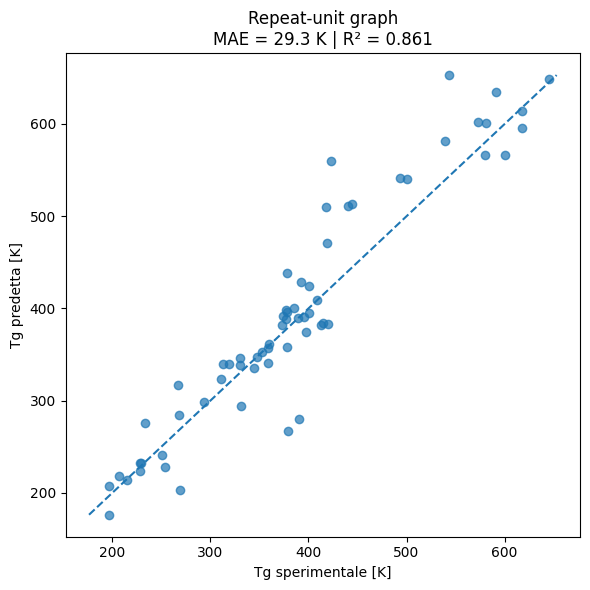

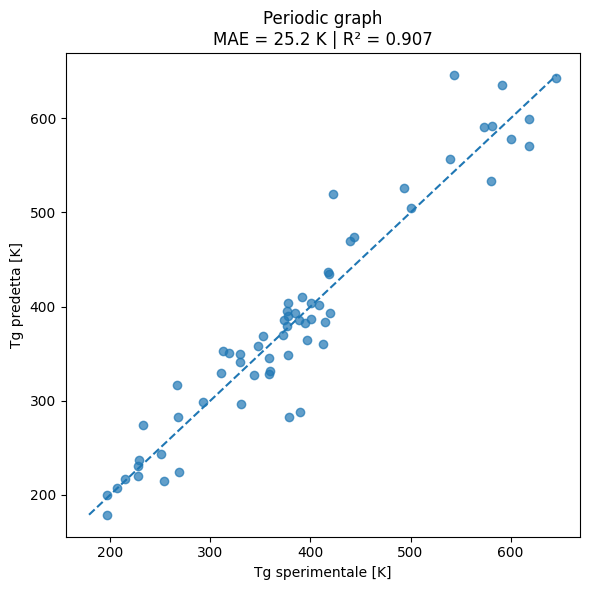

In [14]:
for label, pred, score in [
    ("Repeat-unit graph", pred_standard, standard_metrics),
    ("Periodic graph", pred_periodic, periodic_metrics),
]:
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, pred, alpha=0.7)

    low = min(y_test.min(), pred.min())
    high = max(y_test.max(), pred.max())
    plt.plot([low, high], [low, high], linestyle="--")

    plt.xlabel("Tg sperimentale [K]")
    plt.ylabel("Tg predetta [K]")
    plt.title(
        f"{label}\n"
        f"MAE = {score['MAE_K']:.1f} K | R² = {score['R2']:.3f}"
    )

    plt.tight_layout()
    filename = label.lower().replace(" ", "_").replace("-", "_") + ".png"
    plt.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
